In [1]:
import pandas as pd

df = pd.read_csv("datasets/student-lifestyle-and-stress-dataset.csv")

# get dataset information

print(df.info())
print(df.describe())

# get null values
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  str    
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 1.8 MB
None
        Sleep_Hours   Study_Hours  Social_Media_Hours    Attendance  \
count  24167.000000  24223.000000        24188.000000  24195.000000   
mean       6.458948      4.696477            3.555614     81.270961   
std        1.504228      2.240148            1.901528     12.052045   
min        2.0085

In [2]:
# one hot encode categorical values
df = pd.get_dummies(df, columns=["Student_Type"])
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)
df

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level,Student_Type_college,Student_Type_school,Student_Type_working_student
0,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1,0,1,0
1,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1,0,1,0
2,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1,1,0,0
3,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0,0,1,0
4,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
25495,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0,1,0,0
25496,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1,0,1,0
25497,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1,1,0,0
25498,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0,0,1,0


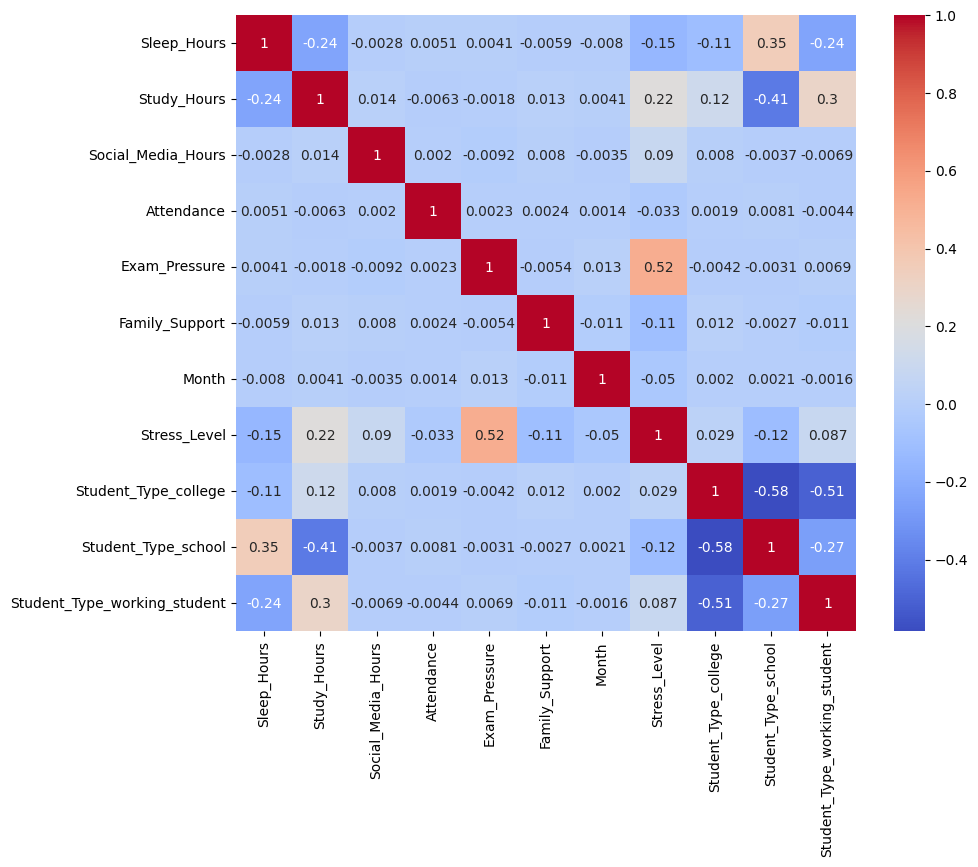

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# get correlation matrix

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [4]:
# extract features and target value
X = df.drop(columns=["Stress_Level"])
y = df["Stress_Level"]

In [5]:
from sklearn.model_selection import train_test_split

# create training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# for each training and testing sets, fill null values

# train mean is used for both training and testing null values because training must be the only source of truth
for col in X_train.select_dtypes(include="number"):
    train_mean = X_train[col].mean()
    X_train[col] = X_train[col].fillna(train_mean)
    X_test[col] = X_test[col].fillna(train_mean)
    

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

continuous_cols = ["Sleep_Hours", "Study_Hours", "Social_Media_Hours", "Attendance", "Exam_Pressure", "Family_Support", "Month"]

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# use SMOTE (Synthetic Minority Over-sampling Technique) to fix class imbalance in machine learning datasets

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [9]:
# train models

logistic_reg_model = LogisticRegression(random_state=42)
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

logistic_reg_model.fit(X_train_balanced, y_train_balanced)
random_forest_model.fit(X_train_balanced, y_train_balanced)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [10]:
# logistic regression
threshold = 0.56
logistic_reg_model_y_prob = logistic_reg_model.predict_proba(X_test)[:, 1]
logistic_reg_model_y_pred = (logistic_reg_model_y_prob >= threshold).astype(int)

# random forest
random_forest_model_y_pred = random_forest_model.predict(X_test)

In [11]:
from sklearn.metrics import classification_report

print("CLASSIFICATION REPORTS")
print()
print("LOGISTIC REGRESSION:")
print(classification_report(y_test, logistic_reg_model_y_pred))
print()
print("RANDOM FOREST")
print(classification_report(y_test, random_forest_model_y_pred))

CLASSIFICATION REPORTS

LOGISTIC REGRESSION:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      3545
           1       0.65      0.74      0.69      1555

    accuracy                           0.80      5100
   macro avg       0.77      0.78      0.77      5100
weighted avg       0.81      0.80      0.80      5100


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      3545
           1       0.70      0.66      0.68      1555

    accuracy                           0.81      5100
   macro avg       0.78      0.77      0.77      5100
weighted avg       0.81      0.81      0.81      5100



In [12]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, logistic_reg_model_y_pred)

array([[2923,  622],
       [ 399, 1156]])